## Setup

In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 20  # drop to 5 for a fast demo run

print(f"Device: {DEVICE}")
print(f"Epochs: {EPOCHS}")

Device: cuda
Epochs: 20


In [2]:
corpus_path = os.path.join(PROJECT_ROOT, "task1_text_generation", "data", "corpus.txt")
with open(corpus_path, "r", encoding="utf-8") as f:
    corpus = f.read()

print(f"Corpus: {len(corpus):,} chars, {len(corpus.split()):,} words")

Corpus: 83,357 chars, 12,288 words


## Part 1 - Markov Chain models

Markov chains are the baseline. They learn transition probabilities between n-gram states with no gradient descent — counting and normalizing only. Character-level uses order-5 (5 preceding characters), word-level uses order-2 (bigrams).

In [3]:
from task1_text_generation.train import train_markov_char, train_markov_word

char_mcm, char_mcm_stats = train_markov_char(corpus, order=5)
word_mcm, word_mcm_stats = train_markov_word(corpus, order=2)


--- Training Character-level Markov Chain (order=5) ---
  Training time: 0.05s
  Memory delta: 2.5 MB
  States learned: 9174

--- Training Word-level Markov Chain (order=2) ---
  Training time: 0.17s
  Memory delta: 2.0 MB
  States learned: 4629


In [4]:
print("--- Character-level Markov Chain samples ---\n")
for prompt in ["The ancient forest", "Science reveals", "The computer proc"]:
    out = char_mcm.generate_text(length=180, seed_text=prompt, mode="char", seed_value=7)
    print(f"[{prompt!r}]\n{out}\n")

print("\n--- Word-level Markov Chain samples ---\n")
for prompt in ["the ancient forest stretches", "the computer processes data", "many believe that the"]:
    out = word_mcm.generate_text(length=30, seed_text=prompt, mode="word", seed_value=7)
    print(f"[{prompt!r}]\n{out}\n")

--- Character-level Markov Chain samples ---

['The ancient forest']
The artist expresses skills. On the flavor creaties cannot discuss innovatively. When the structures prepares the pictured topics, the methods cannot discoveries of part of how the

['Science reveals']
ScienPeople have always been drawn to the realm of innovative technique tastes generously acrosses the prevents cannot discuss ancient markets become more central.

Experts agree t

['The computer proc']
The connection between the very maintains and the prevents and exotic systematical world takes notice. Understated.

The diet healthy grains. The course advances thoughtfully towar


--- Word-level Markov Chain samples ---

['the ancient forest stretches']
the ancient trees spreads silently. significantly, one cannot discuss remote monuments without mentioning how the culture developed the structures that make life restorative. the importance of the rolling hills grows

['the computer processes data']
the computer proce

## Part 2 - Neural models (RNN and LSTM)

We train four neural models: character- and word-level RNN and LSTM. All use:

- Embedding layer (`embed_dim=64`)
- 2 stacked recurrent layers (`hidden_dim=128`)
- Dropout `0.2`
- Linear output projection to vocabulary size
- Adam with StepLR, gradient clipping at max-norm 1.0

Character models use `seq_length=100`; word models use `seq_length=20` (since words carry more information per token).

The training helpers (`train_neural_model`) live in `task1_text_generation/train.py` and return `(model, tokenizer, stats)` — we store those so we can re-use the trained models for generation and comparison later.

In [5]:
from task1_text_generation.models.rnn_model import RNNModel
from task1_text_generation.models.lstm_model import LSTMModel
from shared.tokenizer import CharTokenizer, WordTokenizer
from task1_text_generation.train import train_neural_model

### 2a. Character-level RNN

In [6]:
char_tok_rnn = CharTokenizer()
char_tok_rnn.fit(corpus)

char_rnn = RNNModel(
    vocab_size=char_tok_rnn.vocab_size,
    embed_dim=64, hidden_dim=128, num_layers=2, dropout=0.2,
)
char_rnn, char_tok_rnn, char_rnn_stats = train_neural_model(
    char_rnn, char_tok_rnn, corpus, mode="char",
    seq_length=100, batch_size=64, epochs=EPOCHS, lr=0.003,
    device=DEVICE, model_name="Char RNN",
)


--- Training Char RNN ---
  Epoch 1/20, Loss: 1.0915
  Epoch 5/20, Loss: 0.7682
  Epoch 10/20, Loss: 0.7094
  Epoch 15/20, Loss: 0.6816
  Epoch 20/20, Loss: 0.6673
  Training time: 101.57s
  Memory delta: 817.5 MB
  Final loss: 0.6673


### 2b. Word-level RNN

In [7]:
word_tok_rnn = WordTokenizer()
word_tok_rnn.fit(corpus)

word_rnn = RNNModel(
    vocab_size=word_tok_rnn.vocab_size,
    embed_dim=64, hidden_dim=128, num_layers=2, dropout=0.2,
)
word_rnn, word_tok_rnn, word_rnn_stats = train_neural_model(
    word_rnn, word_tok_rnn, corpus, mode="word",
    seq_length=20, batch_size=32, epochs=EPOCHS, lr=0.003,
    device=DEVICE, model_name="Word RNN",
)


--- Training Word RNN ---
  Epoch 1/20, Loss: 2.6670
  Epoch 5/20, Loss: 1.1191
  Epoch 10/20, Loss: 0.9108
  Epoch 15/20, Loss: 0.8251
  Epoch 20/20, Loss: 0.7789
  Training time: 17.96s
  Memory delta: 0.0 MB
  Final loss: 0.7789


### 2c. Character-level LSTM

In [8]:
char_tok_lstm = CharTokenizer()
char_tok_lstm.fit(corpus)

char_lstm = LSTMModel(
    vocab_size=char_tok_lstm.vocab_size,
    embed_dim=64, hidden_dim=128, num_layers=2, dropout=0.2,
)
char_lstm, char_tok_lstm, char_lstm_stats = train_neural_model(
    char_lstm, char_tok_lstm, corpus, mode="char",
    seq_length=100, batch_size=64, epochs=EPOCHS, lr=0.003,
    device=DEVICE, model_name="Char LSTM",
)


--- Training Char LSTM ---
  Epoch 1/20, Loss: 0.9613
  Epoch 5/20, Loss: 0.3781
  Epoch 10/20, Loss: 0.3220
  Epoch 15/20, Loss: 0.2998
  Epoch 20/20, Loss: 0.2890
  Training time: 107.61s
  Memory delta: 1.5 MB
  Final loss: 0.2890


### 2d. Word-level LSTM

In [9]:
word_tok_lstm = WordTokenizer()
word_tok_lstm.fit(corpus)

word_lstm = LSTMModel(
    vocab_size=word_tok_lstm.vocab_size,
    embed_dim=64, hidden_dim=128, num_layers=2, dropout=0.2,
)
word_lstm, word_tok_lstm, word_lstm_stats = train_neural_model(
    word_lstm, word_tok_lstm, corpus, mode="word",
    seq_length=20, batch_size=32, epochs=EPOCHS, lr=0.003,
    device=DEVICE, model_name="Word LSTM",
)


--- Training Word LSTM ---
  Epoch 1/20, Loss: 3.9950
  Epoch 5/20, Loss: 1.3714
  Epoch 10/20, Loss: 1.0243
  Epoch 15/20, Loss: 0.8903
  Epoch 20/20, Loss: 0.8228
  Training time: 20.43s
  Memory delta: 0.0 MB
  Final loss: 0.8228


## Part 3 - Loss curves

Per-epoch training loss for the four neural models. Markov chains are excluded since they are count-based and have no loss signal.

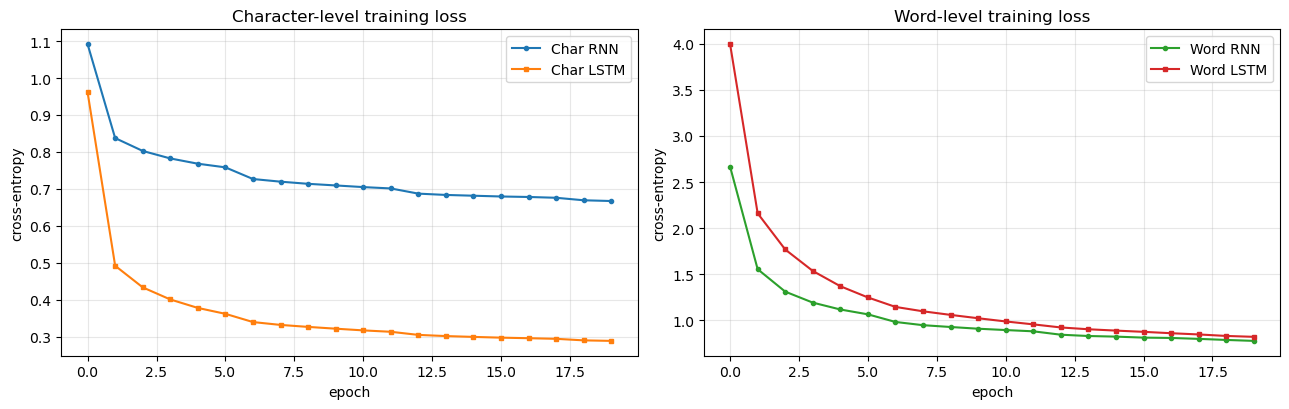

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=False)

axes[0].plot(char_rnn_stats["losses"],  label="Char RNN",  marker="o", markersize=3)
axes[0].plot(char_lstm_stats["losses"], label="Char LSTM", marker="s", markersize=3)
axes[0].set_title("Character-level training loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(word_rnn_stats["losses"],  label="Word RNN",  marker="o", markersize=3, color="C2")
axes[1].plot(word_lstm_stats["losses"], label="Word LSTM", marker="s", markersize=3, color="C3")
axes[1].set_title("Word-level training loss")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("cross-entropy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part 4 - Comparison across all six models

We re-use `evaluate_text_gen_models` from `task1_text_generation/evaluate.py`, which runs 10 character-level prompts and 10 word-level prompts through every model and returns a formatted table. The helper expects a single `results` dict keyed by model name, so we assemble it here.

In [11]:
from task1_text_generation.evaluate import evaluate_text_gen_models

results = {
    "char_mcm":  (char_mcm,  None,          char_mcm_stats),
    "word_mcm":  (word_mcm,  None,          word_mcm_stats),
    "char_rnn":  (char_rnn,  char_tok_rnn,  char_rnn_stats),
    "word_rnn":  (word_rnn,  word_tok_rnn,  word_rnn_stats),
    "char_lstm": (char_lstm, char_tok_lstm, char_lstm_stats),
    "word_lstm": (word_lstm, word_tok_lstm, word_lstm_stats),
}

report = evaluate_text_gen_models(results, device=DEVICE)


TEXT GENERATION MODELS - TRAINING PERFORMANCE COMPARISON
+-------------------+-----------------+----------------+--------------+
| Model             | Training Time   | Memory Usage   | Final Loss   |
+===================+=================+================+==============+
| Char Markov Chain | 0.05s           | 2.5 MB         | N/A          |
+-------------------+-----------------+----------------+--------------+
| Word Markov Chain | 0.17s           | 2.0 MB         | N/A          |
+-------------------+-----------------+----------------+--------------+
| Char RNN          | 101.57s         | 817.5 MB       | 0.6673       |
+-------------------+-----------------+----------------+--------------+
| Word RNN          | 17.96s          | 0.0 MB         | 0.7789       |
+-------------------+-----------------+----------------+--------------+
| Char LSTM         | 107.61s         | 1.5 MB         | 0.2890       |
+-------------------+-----------------+----------------+--------------+
| Word

## Part 5 - Free-form sampling

Drop in any prompt here and compare what each architecture produces. Temperature controls how adventurous the neural models are — lower values stay closer to the most likely next token, higher values take more risks.

In [12]:
CHAR_PROMPT = "The scientist discovered"
WORD_PROMPT = "the scientist discovered that"
TEMPERATURE = 0.8

print(f"--- Character-level, prompt={CHAR_PROMPT!r} ---\n")
print("Markov Chain:")
print(char_mcm.generate_text(length=160, seed_text=CHAR_PROMPT, mode="char", seed_value=1), "\n")
print("RNN:")
print(char_rnn.generate(char_tok_rnn, CHAR_PROMPT, length=120, temperature=TEMPERATURE, mode="char", device=DEVICE), "\n")
print("LSTM:")
print(char_lstm.generate(char_tok_lstm, CHAR_PROMPT, length=120, temperature=TEMPERATURE, mode="char", device=DEVICE), "\n")

print(f"\n--- Word-level, prompt={WORD_PROMPT!r} ---\n")
print("Markov Chain:")
print(word_mcm.generate_text(length=30, seed_text=WORD_PROMPT, mode="word", seed_value=1), "\n")
print("RNN:")
print(word_rnn.generate(word_tok_rnn, WORD_PROMPT, length=25, temperature=TEMPERATURE, mode="word", device=DEVICE), "\n")
print("LSTM:")
print(word_lstm.generate(word_tok_lstm, WORD_PROMPT, length=25, temperature=TEMPERATURE, mode="word", device=DEVICE), "\n")

--- Character-level, prompt='The scientist discovered' ---

Markov Chain:
The strategically. Therefore, the harmonious organs. As the grows as the profoundaries define therapeutic achievements. When the mysteries of our view of majest 

RNN:
The scientist discovered expently. Both the study of how the recovery maintains creatively, transforming our view of sauces. The connection betw 

LSTM:
The scientist discovered practically among the rigorous phenomena. Additionally, the evidence analyzes theoretically among the enduring achievem 


--- Word-level, prompt='the scientist discovered that' ---

Markov Chain:
the scientist explains the very systems we depend upon. nevertheless, the connection between the road and the comprehensive world takes notice. the role of travel. in the realm of exceptional 

RNN:
the scientist <UNK> that helps melody in many ways. as the equation measures carefully, the empirical forces continue to evolve. through fresh effort, the meal tastes traditionally tow